<a href="https://colab.research.google.com/github/yoginikumar0608-gh/GenZSpace/blob/main/AI_Face_Generator_Using_GAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
# Cell 1 - Import Libraries

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [50]:
# Cell 2 - Download Face Dataset

from sklearn.datasets import fetch_olivetti_faces

print("Downloading face dataset...")

faces_dataset = fetch_olivetti_faces(
    shuffle=True,
    random_state=42
)

faces = faces_dataset.images

print("Dataset downloaded successfully!")
print("Number of images:", len(faces))
print("Image shape:", faces.shape)

Dataset downloaded successfully!
Number of images: 400
Image shape: (400, 64, 64)


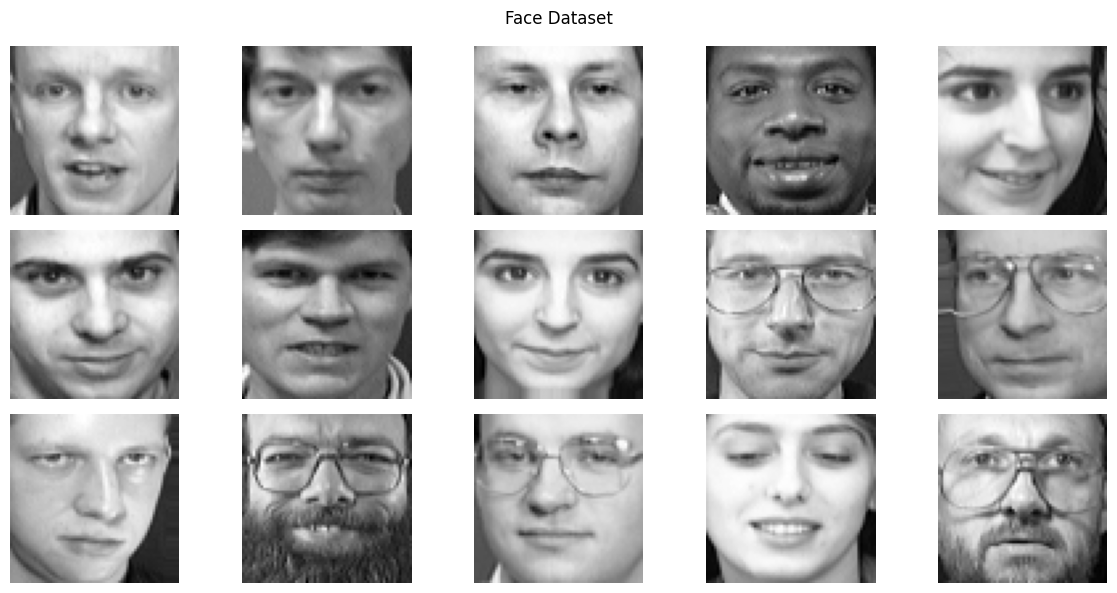

In [51]:
# Cell 3 - Display Sample Faces

plt.figure(figsize=(12, 6))

for i in range(15):

    plt.subplot(3, 5, i + 1)

    plt.imshow(
        faces[i],
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle("Face Dataset")

plt.tight_layout()
plt.show()

In [52]:
# Cell 4 - Prepare Dataset

faces = faces.astype("float32")

# Convert pixel range from [0, 1] to [-1, 1]
faces = (faces - 0.5) * 2.0

# Add channel dimension
faces = faces[..., np.newaxis]

print("Final dataset shape:", faces.shape)
print("Minimum pixel value:", faces.min())
print("Maximum pixel value:", faces.max())

Final dataset shape: (400, 64, 64, 1)
Minimum pixel value: -1.0
Maximum pixel value: 1.0


In [53]:
# Cell 5 - Create TensorFlow Dataset

BATCH_SIZE = 32

train_dataset = tf.data.Dataset.from_tensor_slices(faces)

train_dataset = train_dataset.shuffle(
    len(faces)
)

train_dataset = train_dataset.batch(
    BATCH_SIZE
)

train_dataset = train_dataset.prefetch(
    tf.data.AUTOTUNE
)

print("Training dataset ready!")
print("Batch size:", BATCH_SIZE)

Training dataset ready!
Batch size: 32


In [54]:
# Cell 6 - Build Generator

LATENT_DIM = 100

def build_generator():

    model = tf.keras.Sequential(name="Generator")

    # Random noise input
    model.add(layers.Input(shape=(LATENT_DIM,)))

    # Convert noise into a small feature map
    model.add(
        layers.Dense(
            8 * 8 * 128,
            use_bias=False
        )
    )

    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # Reshape into 8x8 image-like feature map
    model.add(
        layers.Reshape((8, 8, 128))
    )

    # 8x8 → 16x16
    model.add(
        layers.Conv2DTranspose(
            64,
            kernel_size=4,
            strides=2,
            padding="same",
            use_bias=False
        )
    )

    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # 16x16 → 32x32
    model.add(
        layers.Conv2DTranspose(
            32,
            kernel_size=4,
            strides=2,
            padding="same",
            use_bias=False
        )
    )

    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # 32x32 → 64x64
    model.add(
        layers.Conv2DTranspose(
            1,
            kernel_size=4,
            strides=2,
            padding="same",
            activation="tanh"
        )
    )

    return model


generator = build_generator()

generator.summary()

Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8192)           │       819,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8192)           │        32,768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 16, 16, 64)     │       131,072 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 32, 32, 32)     │        32,768 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 64, 64, 1)      │           513 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,016,705 (3.88 MB)

 Trainable params: 1,000,129 (3.82 MB)

 Non-trainable params: 16,576 (64.75 KB)

In [55]:
# Cell 7 - Test Generator

noise = tf.random.normal([1, LATENT_DIM])

generated_image = generator(
    noise,
    training=False
)

print("Generated image shape:", generated_image.shape)

Generated image shape: (1, 64, 64, 1)


In [56]:
# Cell 8 - Build Discriminator

def build_discriminator():

    model = tf.keras.Sequential(name="Discriminator")

    # Input: 64x64 grayscale image
    model.add(
        layers.Input(shape=(64, 64, 1))
    )

    # 64x64 → 32x32
    model.add(
        layers.Conv2D(
            64,
            kernel_size=4,
            strides=2,
            padding="same"
        )
    )
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))

    # 32x32 → 16x16
    model.add(
        layers.Conv2D(
            128,
            kernel_size=4,
            strides=2,
            padding="same"
        )
    )
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))

    # 16x16 → 8x8
    model.add(
        layers.Conv2D(
            256,
            kernel_size=4,
            strides=2,
            padding="same"
        )
    )
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))

    # Convert feature maps into a single vector
    model.add(layers.Flatten())

    # Output: real/fake score
    model.add(layers.Dense(1))

    return model


discriminator = build_discriminator()

discriminator.summary()

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 64)     │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 8, 8, 256)      │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │        16,385 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 674,753 (2.57 MB)

 Trainable params: 673,985 (2.57 MB)

 Non-trainable params: 768 (3.00 KB)

In [57]:
# Cell 9 - Test Discriminator

decision = discriminator(
    generated_image,
    training=False
)

print("Discriminator output:", decision.shape)

Discriminator output: (1, 1)


In [58]:
# Cell 10 - Loss Functions

cross_entropy = tf.keras.losses.BinaryCrossentropy(
    from_logits=True
)


def discriminator_loss(real_output, fake_output):

    real_loss = cross_entropy(
        tf.ones_like(real_output),
        real_output
    )

    fake_loss = cross_entropy(
        tf.zeros_like(fake_output),
        fake_output
    )

    return real_loss + fake_loss


def generator_loss(fake_output):

    return cross_entropy(
        tf.ones_like(fake_output),
        fake_output
    )


print("Loss functions created successfully!")

Loss functions created successfully!


In [59]:
# Cell 11 - Optimizers

generator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0001,
    beta_1=0.5
)

discriminator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0001,
    beta_1=0.5
)

print("Optimizers created successfully!")

Optimizers created successfully!


In [60]:
# Cell 12 - Training Step

@tf.function
def train_step(images):

    # Create random noise
    noise = tf.random.normal(
        [tf.shape(images)[0], LATENT_DIM]
    )

    # Record operations for both models
    with tf.GradientTape() as generator_tape, \
         tf.GradientTape() as discriminator_tape:

        # Generator creates fake faces
        generated_images = generator(
            noise,
            training=True
        )

        # Discriminator checks real images
        real_output = discriminator(
            images,
            training=True
        )

        # Discriminator checks fake images
        fake_output = discriminator(
            generated_images,
            training=True
        )

        # Calculate losses
        gen_loss = generator_loss(
            fake_output
        )

        disc_loss = discriminator_loss(
            real_output,
            fake_output
        )

    # Calculate Generator gradients
    generator_gradients = generator_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    # Calculate Discriminator gradients
    discriminator_gradients = discriminator_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    # Update Generator
    generator_optimizer.apply_gradients(
        zip(
            generator_gradients,
            generator.trainable_variables
        )
    )

    # Update Discriminator
    discriminator_optimizer.apply_gradients(
        zip(
            discriminator_gradients,
            discriminator.trainable_variables
        )
    )

    return gen_loss, disc_loss


print("Training step created successfully!")

Training step created successfully!


In [61]:
# Cell 13 - Prepare Training

EPOCHS = 50

NUM_EXAMPLES = 16

# Fixed random noise
# This lets us see how the same faces improve during training
seed = tf.random.normal(
    [NUM_EXAMPLES, LATENT_DIM]
)

print("Training prepared!")
print("Number of epochs:", EPOCHS)
print("Images generated after each epoch:", NUM_EXAMPLES)

Training prepared!
Number of epochs: 50
Images generated after each epoch: 16


Epoch 1/50 | Generator Loss: 1.8234 | Discriminator Loss: 0.6162


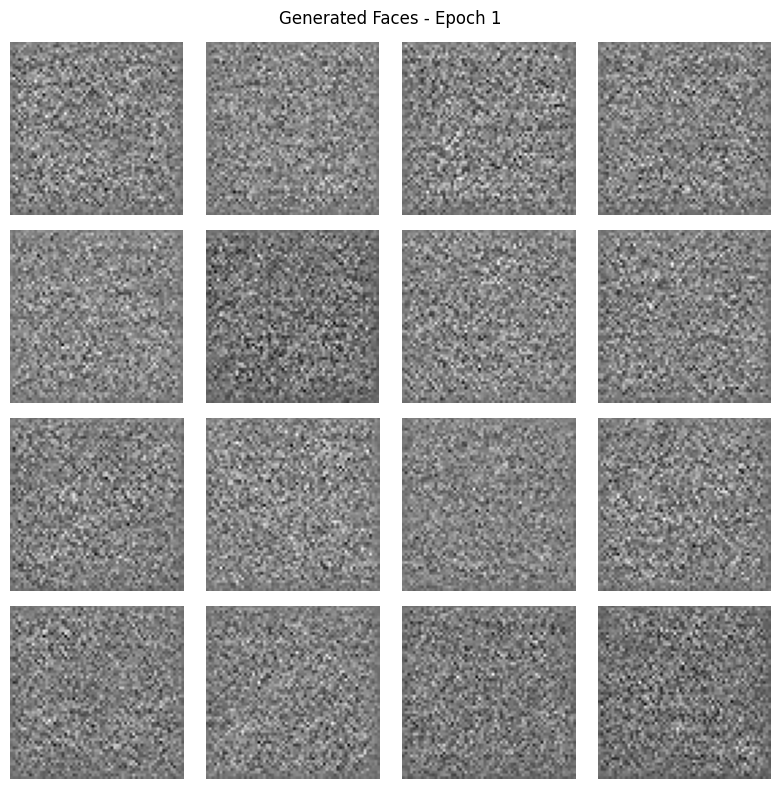

Epoch 2/50 | Generator Loss: 2.9785 | Discriminator Loss: 0.1697
Epoch 3/50 | Generator Loss: 3.5524 | Discriminator Loss: 0.1053
Epoch 4/50 | Generator Loss: 3.8258 | Discriminator Loss: 0.0705
Epoch 5/50 | Generator Loss: 3.9664 | Discriminator Loss: 0.0704


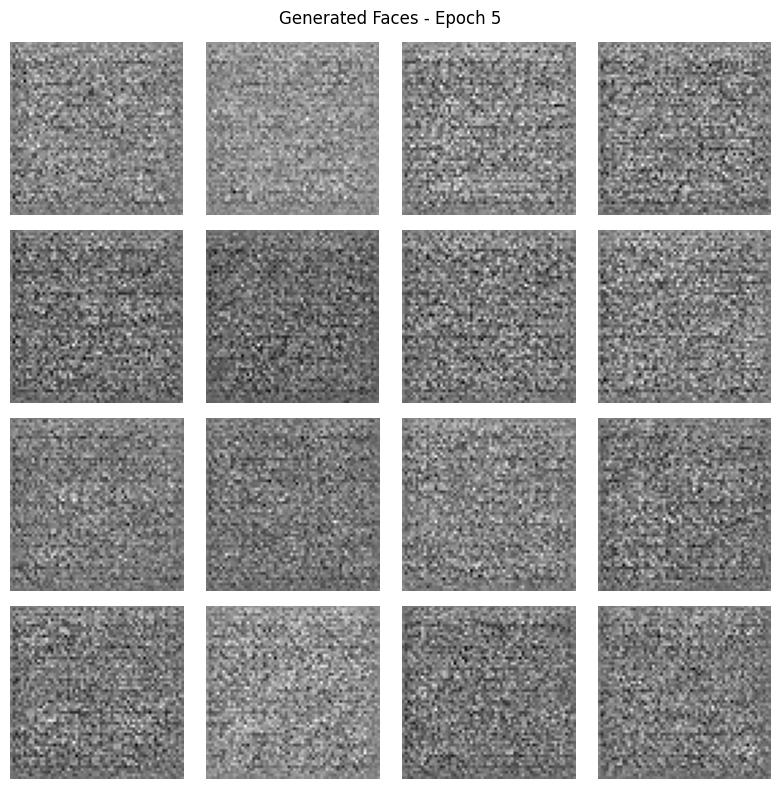

Epoch 6/50 | Generator Loss: 4.0155 | Discriminator Loss: 0.0686
Epoch 7/50 | Generator Loss: 4.1473 | Discriminator Loss: 0.0599
Epoch 8/50 | Generator Loss: 4.4929 | Discriminator Loss: 0.0563
Epoch 9/50 | Generator Loss: 4.3350 | Discriminator Loss: 0.0605
Epoch 10/50 | Generator Loss: 4.3001 | Discriminator Loss: 0.0679


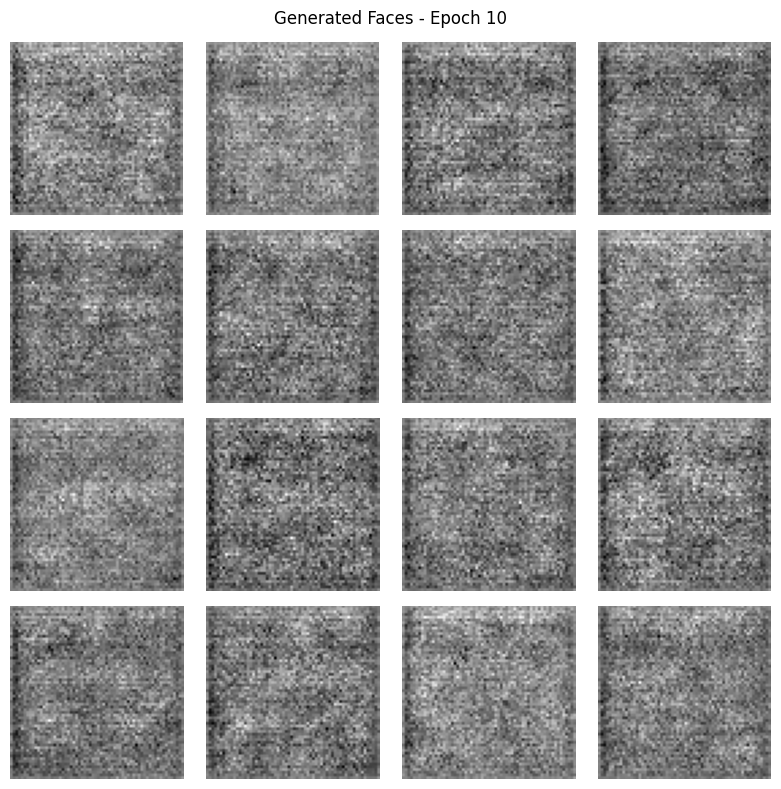

Epoch 11/50 | Generator Loss: 4.4309 | Discriminator Loss: 0.0705
Epoch 12/50 | Generator Loss: 4.3100 | Discriminator Loss: 0.0749
Epoch 13/50 | Generator Loss: 4.0383 | Discriminator Loss: 0.0973
Epoch 14/50 | Generator Loss: 4.0567 | Discriminator Loss: 0.1128
Epoch 15/50 | Generator Loss: 3.9160 | Discriminator Loss: 0.1146


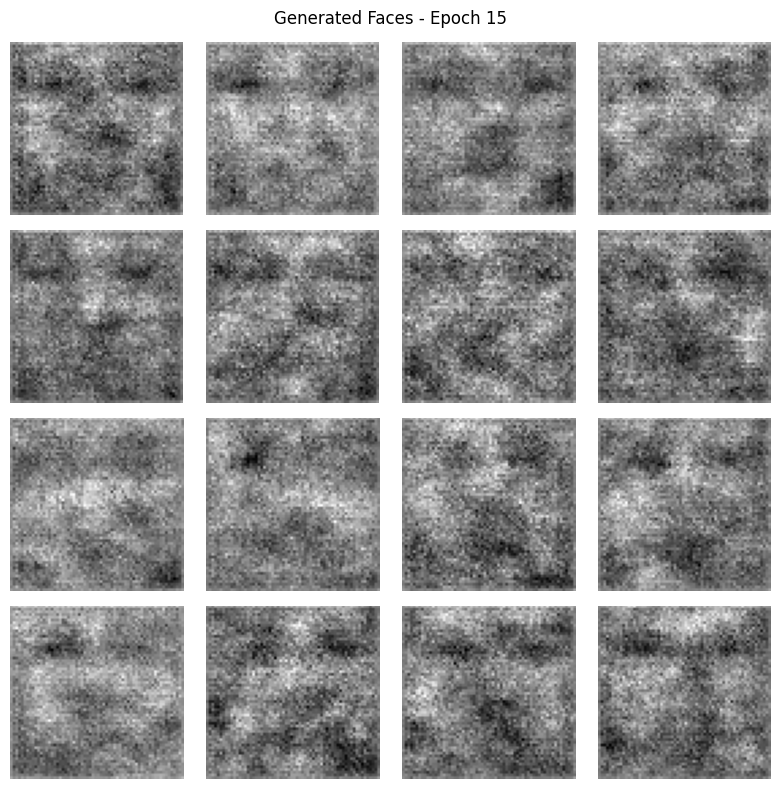

Epoch 16/50 | Generator Loss: 3.9221 | Discriminator Loss: 0.1099
Epoch 17/50 | Generator Loss: 4.1016 | Discriminator Loss: 0.1037
Epoch 18/50 | Generator Loss: 4.0487 | Discriminator Loss: 0.1111
Epoch 19/50 | Generator Loss: 4.2570 | Discriminator Loss: 0.1104
Epoch 20/50 | Generator Loss: 4.4900 | Discriminator Loss: 0.0712


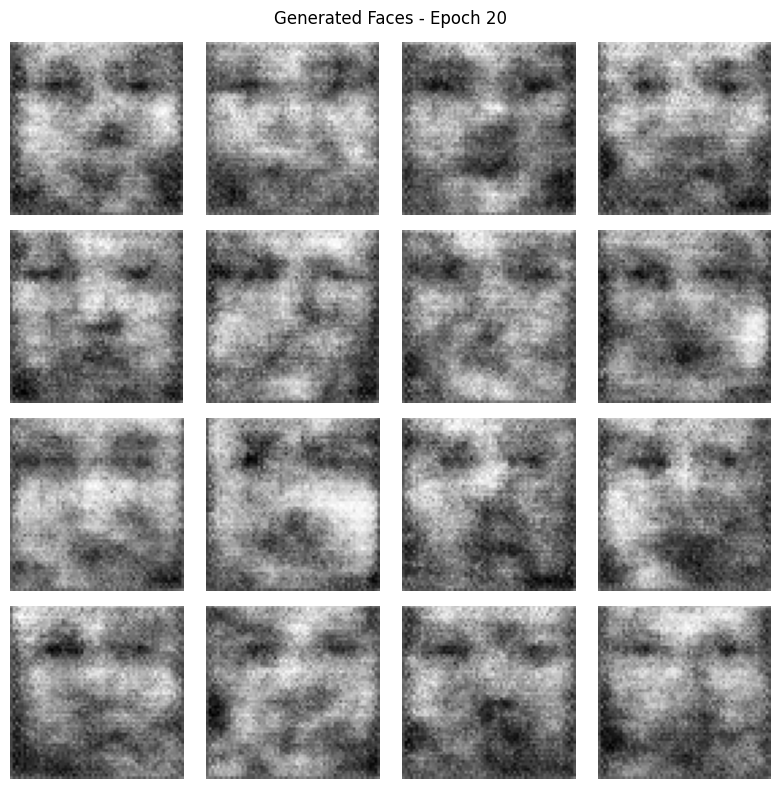

Epoch 21/50 | Generator Loss: 4.4106 | Discriminator Loss: 0.0788
Epoch 22/50 | Generator Loss: 4.2767 | Discriminator Loss: 0.1032
Epoch 23/50 | Generator Loss: 4.8764 | Discriminator Loss: 0.0776
Epoch 24/50 | Generator Loss: 4.5566 | Discriminator Loss: 0.0683
Epoch 25/50 | Generator Loss: 4.7934 | Discriminator Loss: 0.0588


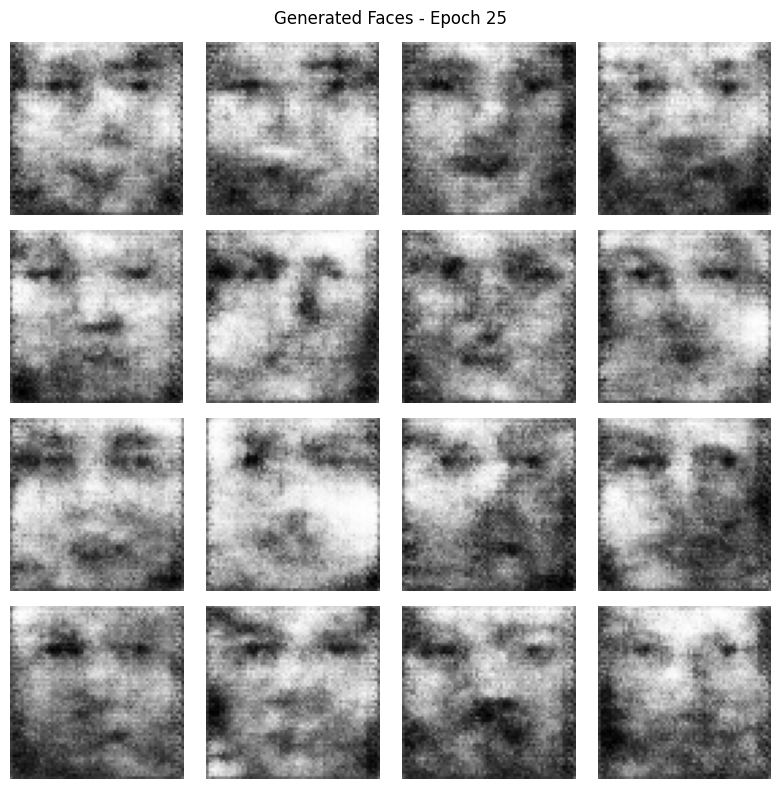

Epoch 26/50 | Generator Loss: 4.9007 | Discriminator Loss: 0.0946
Epoch 27/50 | Generator Loss: 5.2575 | Discriminator Loss: 0.0892
Epoch 28/50 | Generator Loss: 4.6514 | Discriminator Loss: 0.0900
Epoch 29/50 | Generator Loss: 4.8127 | Discriminator Loss: 0.1329
Epoch 30/50 | Generator Loss: 4.9658 | Discriminator Loss: 0.0747


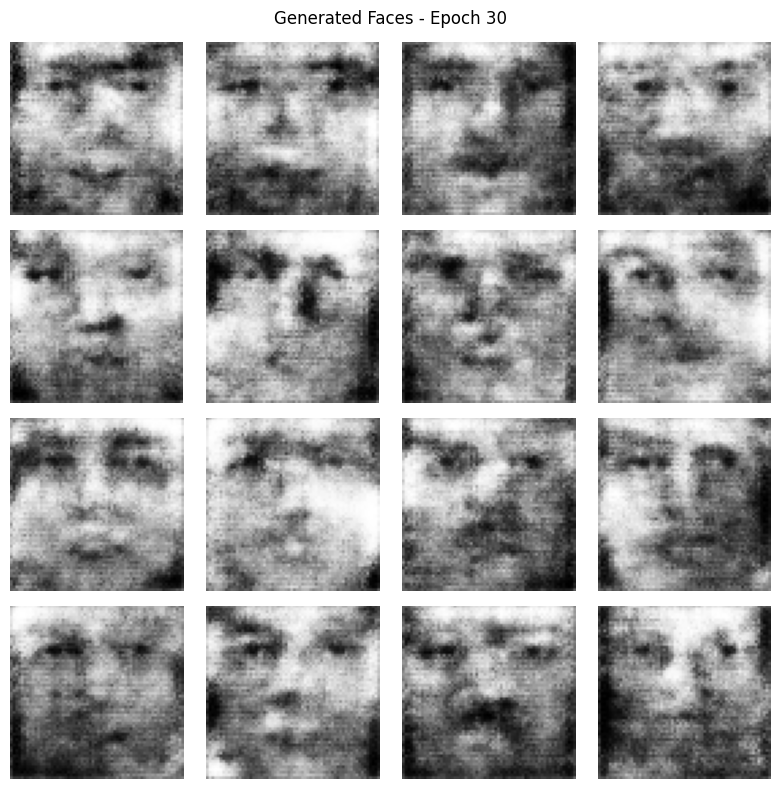

Epoch 31/50 | Generator Loss: 4.7063 | Discriminator Loss: 0.0905
Epoch 32/50 | Generator Loss: 4.9402 | Discriminator Loss: 0.0979
Epoch 33/50 | Generator Loss: 5.0667 | Discriminator Loss: 0.0651
Epoch 34/50 | Generator Loss: 4.9915 | Discriminator Loss: 0.0932
Epoch 35/50 | Generator Loss: 5.0204 | Discriminator Loss: 0.0689


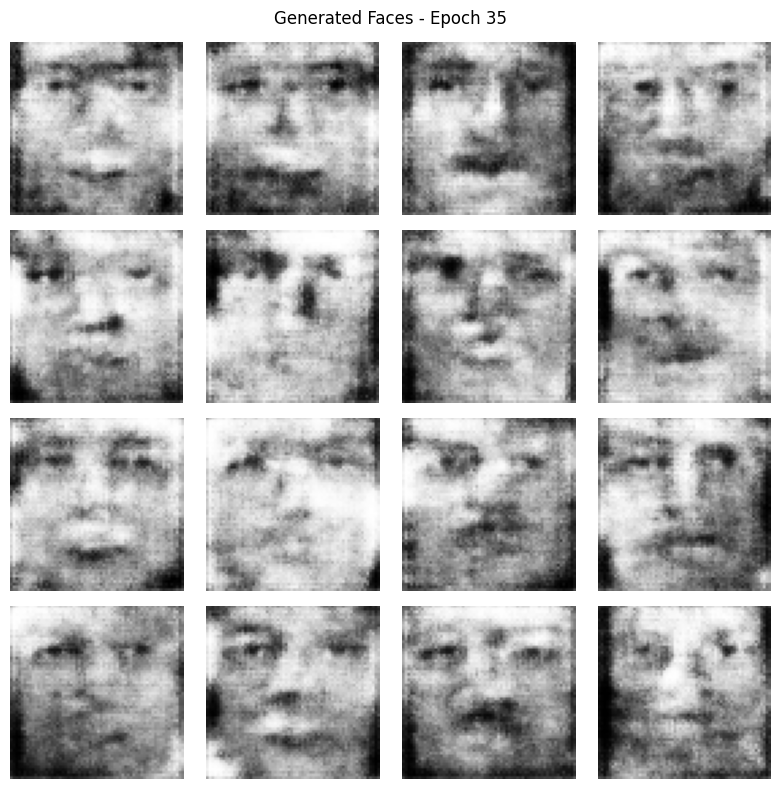

Epoch 36/50 | Generator Loss: 4.8730 | Discriminator Loss: 0.0575
Epoch 37/50 | Generator Loss: 4.9727 | Discriminator Loss: 0.0870
Epoch 38/50 | Generator Loss: 4.8266 | Discriminator Loss: 0.0853
Epoch 39/50 | Generator Loss: 4.5301 | Discriminator Loss: 0.1787
Epoch 40/50 | Generator Loss: 4.7394 | Discriminator Loss: 0.2941


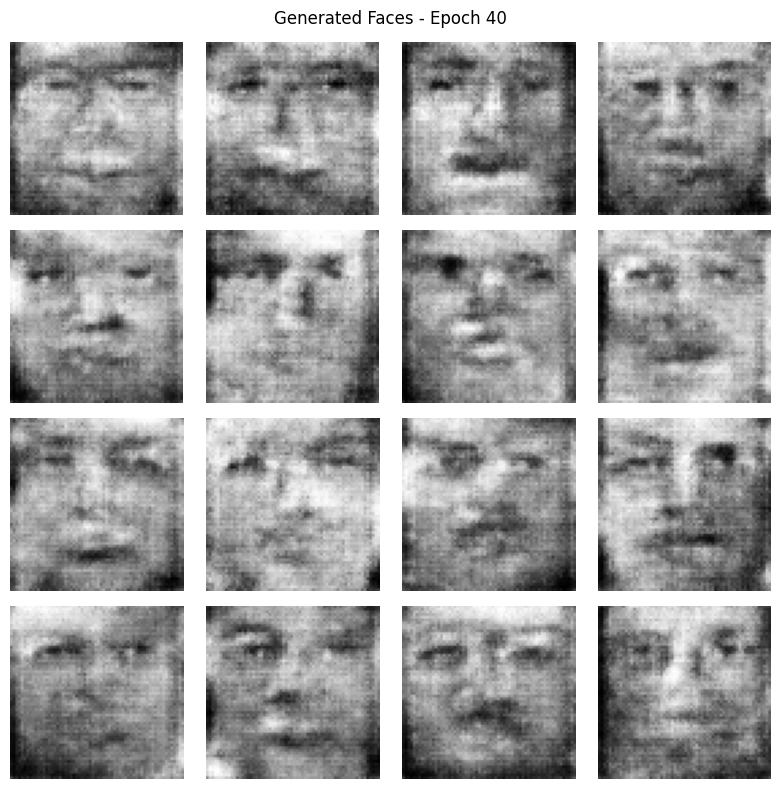

Epoch 41/50 | Generator Loss: 4.0940 | Discriminator Loss: 0.1876
Epoch 42/50 | Generator Loss: 3.7351 | Discriminator Loss: 0.2883
Epoch 43/50 | Generator Loss: 4.2824 | Discriminator Loss: 0.1184
Epoch 44/50 | Generator Loss: 4.0631 | Discriminator Loss: 0.2297
Epoch 45/50 | Generator Loss: 4.0074 | Discriminator Loss: 0.1641


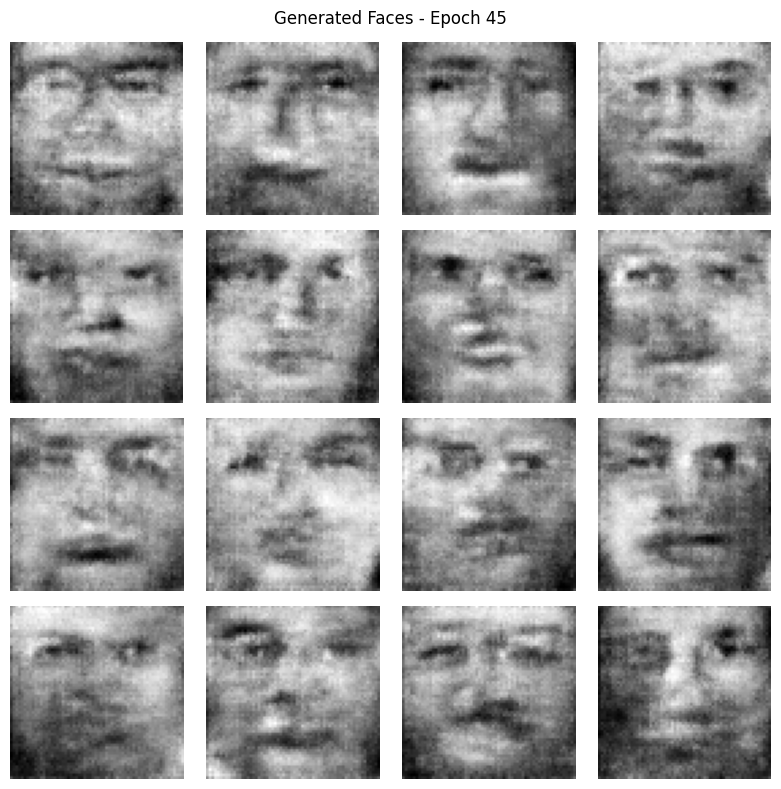

Epoch 46/50 | Generator Loss: 4.3953 | Discriminator Loss: 0.2381
Epoch 47/50 | Generator Loss: 4.2721 | Discriminator Loss: 0.2843
Epoch 48/50 | Generator Loss: 3.7834 | Discriminator Loss: 0.1713
Epoch 49/50 | Generator Loss: 4.0334 | Discriminator Loss: 0.2272
Epoch 50/50 | Generator Loss: 3.8888 | Discriminator Loss: 0.1734


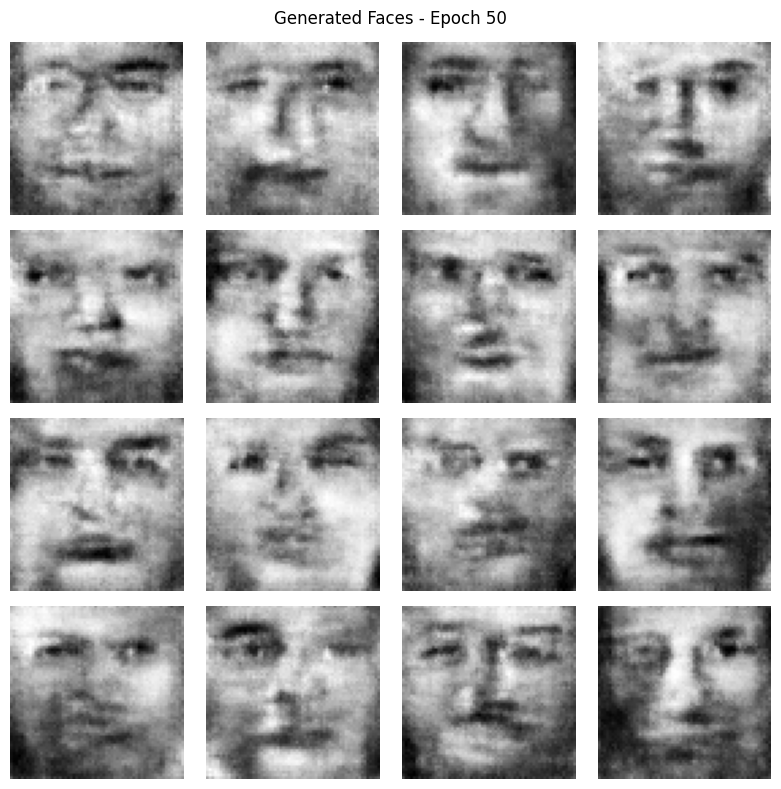

In [62]:
# Cell 14 - Train GAN

def generate_and_display_images(model, epoch, test_input):

    predictions = model(
        test_input,
        training=False
    )

    plt.figure(figsize=(8, 8))

    for i in range(predictions.shape[0]):

        plt.subplot(4, 4, i + 1)

        # Convert [-1, 1] back to [0, 1]
        image = (predictions[i, :, :, 0] + 1) / 2

        plt.imshow(
            image,
            cmap="gray"
        )

        plt.axis("off")

    plt.suptitle(
        f"Generated Faces - Epoch {epoch}"
    )

    plt.tight_layout()
    plt.show()


for epoch in range(1, EPOCHS + 1):

    gen_loss_total = 0
    disc_loss_total = 0
    batches = 0

    for image_batch in train_dataset:

        gen_loss, disc_loss = train_step(
            image_batch
        )

        gen_loss_total += float(gen_loss)
        disc_loss_total += float(disc_loss)
        batches += 1

    avg_gen_loss = gen_loss_total / batches
    avg_disc_loss = disc_loss_total / batches

    print(
        f"Epoch {epoch}/{EPOCHS} | "
        f"Generator Loss: {avg_gen_loss:.4f} | "
        f"Discriminator Loss: {avg_disc_loss:.4f}"
    )

    # Display generated faces every 5 epochs
    if epoch % 5 == 0 or epoch == 1:

        generate_and_display_images(
            generator,
            epoch,
            seed
        )

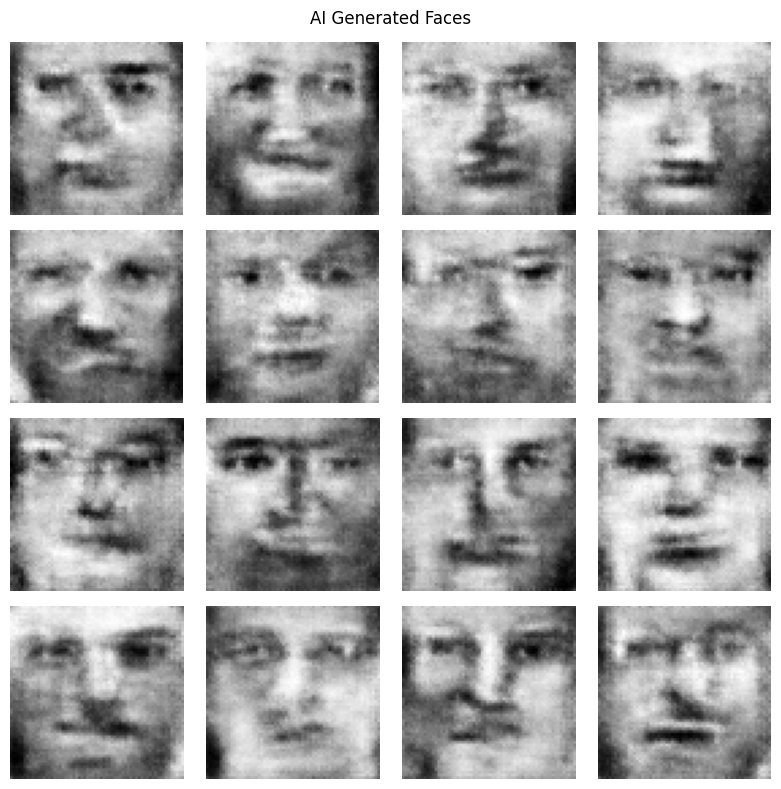

In [63]:
# Cell 15 - Generate New AI Faces

NUM_NEW_FACES = 16

# Generate completely new random noise
random_noise = tf.random.normal(
    [NUM_NEW_FACES, LATENT_DIM]
)

# Generate faces
new_faces = generator(
    random_noise,
    training=False
)

# Display faces
plt.figure(figsize=(8, 8))

for i in range(NUM_NEW_FACES):

    plt.subplot(4, 4, i + 1)

    # Convert [-1, 1] to [0, 1]
    image = (new_faces[i, :, :, 0] + 1) / 2

    plt.imshow(
        image,
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle("AI Generated Faces")

plt.tight_layout()
plt.show()

In [64]:
# Cell 16 - Save Generator

generator.save(
    "/content/ai_face_generator.keras"
)

print("Generator saved successfully!")

Generator saved successfully!


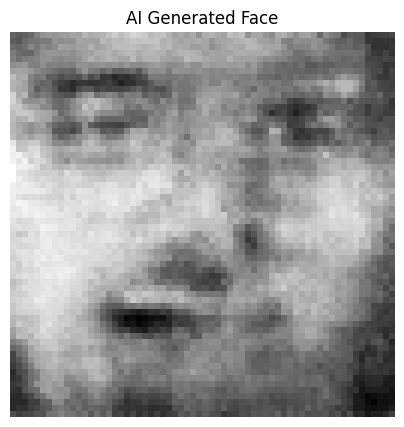

In [65]:
# Cell 17 - Generate a Single AI Face

noise = tf.random.normal([1, LATENT_DIM])

generated_face = generator(
    noise,
    training=False
)

# Convert pixel range from [-1, 1] to [0, 1]
generated_face = (generated_face[0, :, :, 0] + 1) / 2

plt.figure(figsize=(5, 5))

plt.imshow(
    generated_face,
    cmap="gray"
)

plt.title("AI Generated Face")
plt.axis("off")

plt.show()

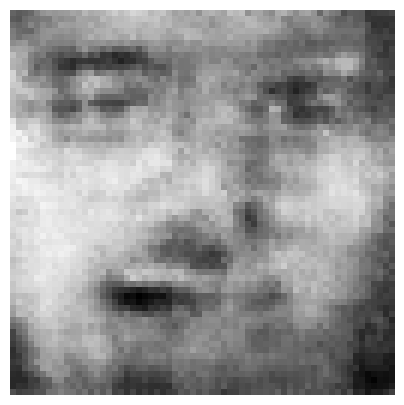

Generated face saved successfully!


In [66]:
# Cell 18 - Save Generated Face

plt.figure(figsize=(5, 5))

plt.imshow(
    generated_face,
    cmap="gray"
)

plt.axis("off")

plt.savefig(
    "/content/generated_face.png",
    bbox_inches="tight",
    pad_inches=0
)

plt.show()

print("Generated face saved successfully!")

In [67]:
# Cell 19 - Download Files

from google.colab import files

files.download("/content/generated_face.png")
files.download("/content/ai_face_generator.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

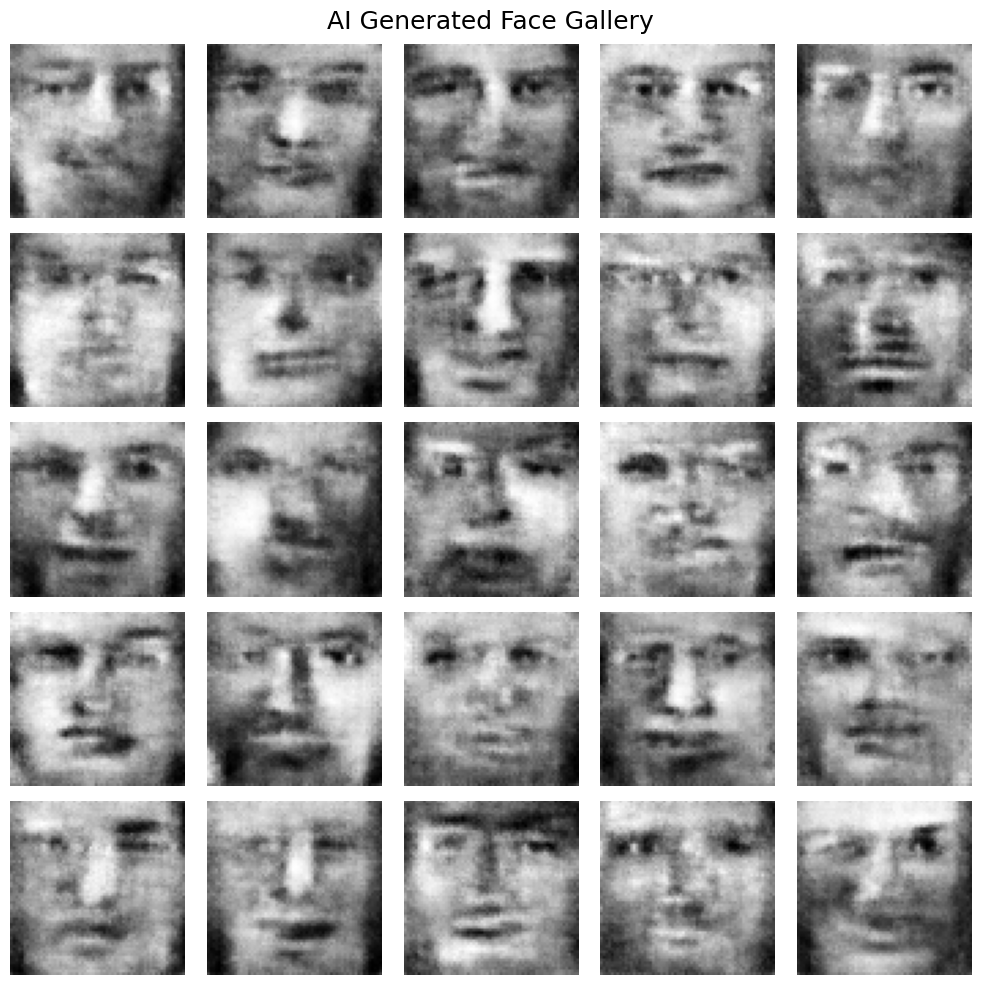

In [68]:
# Cell 20 - Final Face Gallery

NUM_FACES = 25

noise = tf.random.normal([NUM_FACES, LATENT_DIM])

generated_faces = generator(
    noise,
    training=False
)

plt.figure(figsize=(10, 10))

for i in range(NUM_FACES):

    plt.subplot(5, 5, i + 1)

    image = (generated_faces[i, :, :, 0] + 1) / 2

    plt.imshow(
        image,
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle(
    "AI Generated Face Gallery",
    fontsize=18
)

plt.tight_layout()
plt.show()